# Notebook 4 — Validation

Validation of the CDS pricer against market-standard benchmarks.

**Current:** internal self-consistency checks (reprice validation, monotonicity)

**Planned:** Bloomberg CDSW comparison once terminal access is available

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import date

from cds.curves import DiscountCurve, SurvivalCurve
from cds.schedule import build_schedule
from cds.pricer import par_spread, upfront, risky_annuity
from cds.risk import cs01

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.grid':         True,
    'grid.color':        '#e5e5e5',
    'grid.linewidth':    0.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'sans-serif',
    'font.size':         11,
})

BLUE  = '#2563EB'
GREEN = '#16A34A'
RED   = '#DC2626'

with open('../data/dummy/market_data.json') as f:
    mkt = json.load(f)

swap_rates = {float(k): v for k, v in mkt['swap_curve'].items()
              if k != 'comment'}

def parse_spreads(entity):
    return {
        float(k): v
        for k, v in mkt['spread_curves'][entity].items()
        if k not in ('name', 'rating', 'sector', 'recovery', 'comment')
    }

TRADE_DATE = date(2026, 6, 13)
print('Ready.')

Ready.


---
## 1. Reprice Validation — All Entities

In [2]:
entities = {
    'VOD':        ('Vodafone BBB-',  0.40),
    'XOVER':      ('iTraxx XOVER',   0.40),
    'TSLA':       ('Tesla BB+',      0.40),
    'DISTRESSED': ('Distressed CCC', 0.25),
}

all_pass        = True
reprice_results = []

for entity, (name, rec) in entities.items():
    spreads = parse_spreads(entity)
    dc      = DiscountCurve(swap_rates)
    sc      = SurvivalCurve(spreads, dc, recovery=rec, trade_date=TRADE_DATE)

    tenors_sorted = sorted(spreads.keys())
    hazards       = sc._hazards
    entity_pass   = True

    for i, tenor in enumerate(tenors_sorted):
        spread = spreads[tenor]
        npv    = sc._price_cds(
            tenor, spread / 10_000,
            tenors_sorted[:i+1],
            hazards[:i+1]
        )
        passed = abs(npv) < 1e-4
        if not passed:
            entity_pass = False
            all_pass    = False
        reprice_results.append({
            'entity': name, 'tenor': tenor,
            'spread': spread, 'npv': npv, 'pass': passed,
        })

    print(f'{name:<22}: {"✓ PASS" if entity_pass else "✗ FAIL"}')

print()
print(f'Overall: {"ALL PASS ✓" if all_pass else "FAILURES DETECTED ✗"}')

Vodafone BBB-         : ✓ PASS
iTraxx XOVER          : ✓ PASS
Tesla BB+             : ✓ PASS
Distressed CCC        : ✓ PASS

Overall: ALL PASS ✓


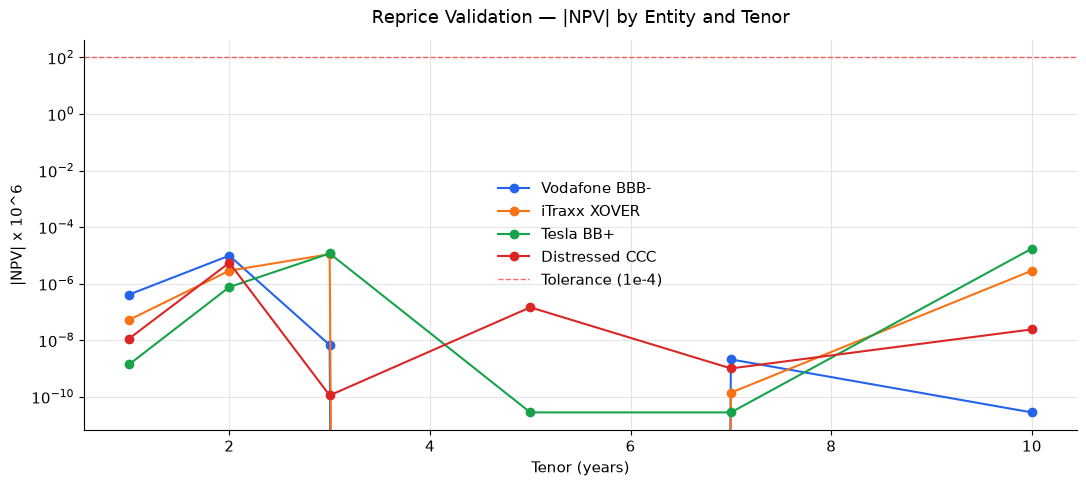

In [3]:
from collections import defaultdict

fig, ax = plt.subplots(figsize=(11, 5))

entity_names = list(dict.fromkeys(r['entity'] for r in reprice_results))
colours_map  = dict(zip(entity_names, [BLUE, '#F97316', GREEN, RED]))

for ent in entity_names:
    ent_results = [r for r in reprice_results if r['entity'] == ent]
    xs = [r['tenor'] for r in ent_results]
    ys = [abs(r['npv']) * 1e6 for r in ent_results]
    ax.plot(xs, ys, 'o-', label=ent, color=colours_map[ent], lw=1.5, ms=6)

ax.axhline(100, color='red', lw=1, linestyle='--', alpha=0.6, label='Tolerance (1e-4)')
ax.set_title('Reprice Validation — |NPV| by Entity and Tenor', pad=12)
ax.set_xlabel('Tenor (years)')
ax.set_ylabel('|NPV| x 10^6')
ax.legend(frameon=False)
ax.set_yscale('log')

plt.tight_layout()
plt.savefig('../outputs/04a_reprice_validation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Monotonicity Check

In [4]:
print('Monotonicity check:')
t_fine = np.linspace(0.01, 10, 1000)

for entity, (name, rec) in entities.items():
    spreads = parse_spreads(entity)
    dc      = DiscountCurve(swap_rates)
    sc      = SurvivalCurve(spreads, dc, recovery=rec, trade_date=TRADE_DATE)
    sps     = [sc.survival_prob(t) for t in t_fine]
    mono    = all(sps[i] > sps[i+1] for i in range(len(sps)-1))
    print(f'  {name:<22}: {"✓ Strictly decreasing" if mono else "✗ NON-MONOTONIC"}')

Monotonicity check:
  Vodafone BBB-         : ✓ Strictly decreasing
  iTraxx XOVER          : ✓ Strictly decreasing
  Tesla BB+             : ✓ Strictly decreasing
  Distressed CCC        : ✓ Strictly decreasing


---
## 3. Bootstrapped vs Approximate Hazard Rates

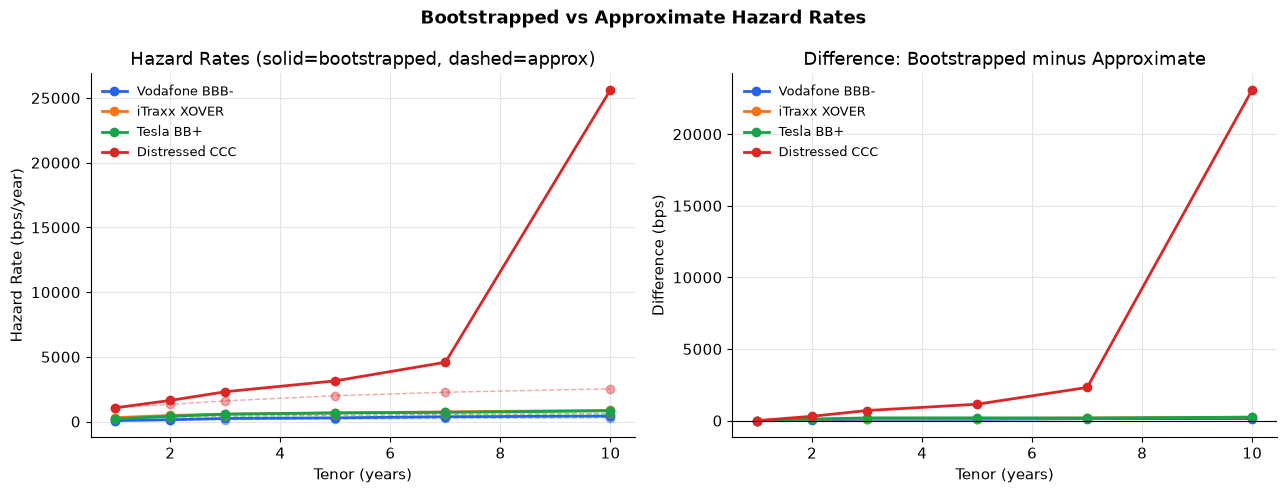

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Bootstrapped vs Approximate Hazard Rates', fontsize=13, fontweight='bold')

colours_list = [BLUE, '#F97316', GREEN, RED]

for ax_idx, ax in enumerate(axes):
    for i, (entity, (name, rec)) in enumerate(entities.items()):
        spreads = parse_spreads(entity)
        dc      = DiscountCurve(swap_rates)
        sc      = SurvivalCurve(spreads, dc, recovery=rec, trade_date=TRADE_DATE)

        tenors_sorted = sorted(spreads.keys())
        bootstrapped  = [sc.hazard_rate(t) * 10_000 for t in tenors_sorted]
        approximate   = [spreads[t] / (1 - rec) for t in tenors_sorted]

        if ax_idx == 0:
            ax.plot(tenors_sorted, bootstrapped, 'o-',
                    color=colours_list[i], label=name, lw=2)
            ax.plot(tenors_sorted, approximate, 'o--',
                    color=colours_list[i], alpha=0.4, lw=1)
        else:
            diff = [b - a for b, a in zip(bootstrapped, approximate)]
            ax.plot(tenors_sorted, diff, 'o-',
                    color=colours_list[i], label=name, lw=2)

    if ax_idx == 0:
        ax.set_title('Hazard Rates (solid=bootstrapped, dashed=approx)')
        ax.set_ylabel('Hazard Rate (bps/year)')
    else:
        ax.axhline(0, color='black', lw=0.8)
        ax.set_title('Difference: Bootstrapped minus Approximate')
        ax.set_ylabel('Difference (bps)')

    ax.set_xlabel('Tenor (years)')
    ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/04b_hazard_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Bloomberg CDSW Comparison (Pending)

Populate `bbg_results` below with Bloomberg CDSW output when terminal access is available.

Target accuracy: within 0.5bps on par spread, within £500 on upfront for £10mm notional.

In [6]:
# Populate with real Bloomberg CDSW output when available
# bbg_results = {
#     'VOD_5Y': {'par_spread': 119.80, 'upfront': 87_500, 'cs01': 4_380}
# }
bbg_results = {}

if not bbg_results:
    print('Bloomberg comparison pending terminal access.')
    print()
    print('Our model output for reference:')
    spreads = parse_spreads('VOD')
    dc      = DiscountCurve(swap_rates)
    sc      = SurvivalCurve(spreads, dc, recovery=0.40, trade_date=TRADE_DATE)
    sch     = build_schedule(TRADE_DATE, date(2031, 6, 20))
    ps      = par_spread(sch, sc, dc, 0.40)
    uf      = upfront(sch, sc, dc, 100, 10_000_000, 0.40)
    c01     = cs01(TRADE_DATE, date(2031, 6, 20), swap_rates, spreads, 100, 10_000_000)
    print(f'  Par Spread: {ps:.2f} bps')
    print(f'  Upfront:    £{uf:,.0f}')
    print(f'  CS01:       £{c01:,.0f} per 1bp')

Bloomberg comparison pending terminal access.

Our model output for reference:
  Par Spread: 120.19 bps
  Upfront:    £88,909
  CS01:       £4,364 per 1bp
